# **Notebook 13 – Feature Engineering Pipeline**

In [21]:
# Load Datset
import pandas as pd 
import numpy as np 
df = pd.read_csv("employee_salary_promotion_dataset.csv")
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3000 entries, 0 to 2999
Data columns (total 18 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Employee_ID               3000 non-null   int64  
 1   Age                       2975 non-null   float64
 2   Experience_Years          3000 non-null   float64
 3   Monthly_Salary            2975 non-null   float64
 4   Performance_Score         2975 non-null   float64
 5   Training_Hours            3000 non-null   float64
 6   Projects_Completed        3000 non-null   int64  
 7   Joining_Date              3000 non-null   object 
 8   Department                2975 non-null   object 
 9   Job_Level                 3000 non-null   object 
 10  Education_Level           2975 non-null   object 
 11  Employment_Type           3000 non-null   object 
 12  Work_Mode                 3000 non-null   object 
 13  Gender                    3000 non-null   object 
 14  Annual_B

## **1. Feature Engineering Workflow**

**Understand the Concept**

- Feature engineering prepares raw data for a machine learning model.
- It includes cleaning, creating, transforming, and selecting features.

**Demonstrate the Concept**

- Load and clean the data.
- Create useful features and prepare them for the model.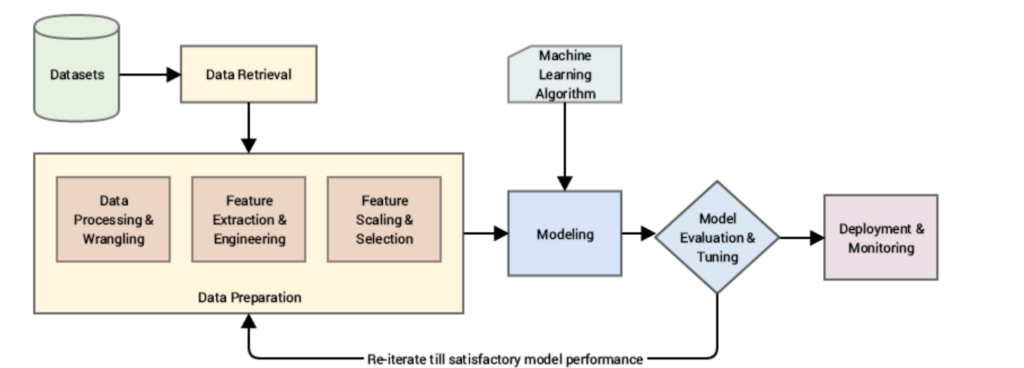

## **2. Train/Test Separation**

**Understand the Concept**

- Train data is used to learn from the data.
- Test data is used to check how well the model performs on new data.

**Demonstrate the Concept**

- Split the data before applying transformations.
- This helps prevent data leakage.

In [22]:
from sklearn.model_selection import train_test_split
# features and target
X = df.drop(columns=["Promoted"])
y = df["Promoted"]

In [23]:
# Split the data
X_train, X_test, y_train, y_test = train_test_split(X, y,test_size=0.2,random_state=42,stratify=y)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (2400, 17)
Testing data: (600, 17)


**Explanation**

- 80% of the data is used for training.
- 20% is kept for testing.

## **3. Pipeline**

**Understand the Concept**

- A pipeline combines multiple data processing steps into one workflow.
  - Handle Missing Values – Fill missing numerical and categorical values.
  - Feature Creation – Create new useful features from existing columns.
  - Numerical Transformation – Scale numerical features.
  - Categorical Transformation – Encode categorical features.
  - Feature Selection – Keep useful features and remove unnecessary ones.
  - Final Transformation – Combine all processed features into model-ready data.
  - Model Training – Train the model using the processed data.



In [24]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler

# Numerical pipeline
numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

# Apply pipeline to numerical data (X)
X_train_num = numerical_pipeline.fit_transform(X_train.select_dtypes(include="number"))
X_test_num = numerical_pipeline.transform(X_test.select_dtypes(include="number"))
print("Training shape:", X_train_num.shape)
print("Testing shape:", X_test_num.shape)

Training shape: (2400, 10)
Testing shape: (600, 10)


**Explanation**

- Missing values are filled using the median.
- Numerical features are then scaled.
- The pipeline applies the same steps consistently to train and test data.

## **4. ColumnTransformer**

**Understand the Concept**

- ColumnTransformer applies different transformations to different columns.
- It is useful when the dataset has both numerical and categorical features.

**Demonstrate the Concept**

- Numerical columns → Fill missing values and scale.
- Categorical columns → Fill missing values and encode.

In [25]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# numerical & categorical columns
numerical_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="object").columns

# pipeline for num & cat
numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

# Combine pipelines
preprocessor = ColumnTransformer([("num", numerical_pipeline, numerical_features),("cat", categorical_pipeline, categorical_features)])

In [26]:
# Fit and transform
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (2400, 1789)
Testing shape: (600, 1789)


**Explanation**

- select_dtypes() automatically selects numerical and categorical columns.
- Numerical features are filled and scaled.
- Categorical features are filled and encoded.
- ColumnTransformer combines both pipelines.

## **5. Numerical Transformations**

**Understand the Concept**

- Numerical transformations change numerical features into a useful format.
- Common steps include filling missing values and scaling.

**Demonstrate the Concept**

- Fill missing numerical values.
- Scale numerical features to a similar range.

In [27]:
# Numerical transformation pipeline
numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])

# Transform numerical features
X_train_num = numerical_pipeline.fit_transform(X_train[numerical_features])
X_test_num = numerical_pipeline.transform(X_test[numerical_features])
print("Training shape:", X_train_num.shape)
print("Testing shape:", X_test_num.shape)

Training shape: (2400, 10)
Testing shape: (600, 10)


**Explanation**

- Missing values are filled using the median.
- StandardScaler puts numerical features on a similar scale.
- The pipeline learns the transformations only from training data.

## **6. Categorical Transformations**

**Understand the Concept**

- Categorical features contain values like department or job level.
- They need to be converted into numbers before modeling.

**Demonstrate the Concept**

- Fill missing categorical values.
- Use One-Hot Encoding to convert categories into numerical features.

In [28]:
# Categorical transformation pipeline
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])
X_train_cat = categorical_pipeline.fit_transform(X_train[categorical_features])
X_test_cat = categorical_pipeline.transform(X_test[categorical_features])
print("Training shape:", X_train_cat.shape)
print("Testing shape:", X_test_cat.shape)

Training shape: (2400, 1779)
Testing shape: (600, 1779)


**Explanation**

- Missing categories are filled with the most common value.
- OneHotEncoder converts categories into numerical columns.
- handle_unknown prevents errors from new categories in test data.

## **7. Feature Creation**

**Understand the Concept**

- Feature creation means making new features from existing data.
- New features can provide more useful information to the model.

**Demonstrate the Concept**

- Create Salary_Per_Experience.
- Create Training_Performance.

In [29]:
# Feature Creation
df["Salary_Per_Experience"] = (df["Monthly_Salary"] / df["Experience_Years"].replace(0, np.nan))
df["Training_Performance"] = (df["Training_Hours"] * df["Performance_Score"])
print(df[["Monthly_Salary","Experience_Years","Salary_Per_Experience","Training_Hours","Performance_Score","Training_Performance"]].head())

   Monthly_Salary  Experience_Years  Salary_Per_Experience  Training_Hours  \
0         35200.0              11.3            3115.044248            52.6   
1         42700.0               9.4            4542.553191             6.8   
2             NaN              16.8                    NaN            30.1   
3         44200.0              30.7            1439.739414            34.4   
4         50500.0              12.7            3976.377953            35.2   

   Performance_Score  Training_Performance  
0                3.9                205.14  
1                4.2                 28.56  
2                3.7                111.37  
3                2.0                 68.80  
4                3.3                116.16  


**Explanation**

- Salary_Per_Experience shows salary compared with experience.
- Training_Performance combines training and performance.

## **8. Feature Selection**

**Understand the Concept**

- Feature selection keeps useful features and removes unnecessary ones.
- It can make the pipeline simpler and more efficient.

**Demonstrate the Concept**

- Remove Employee_ID because it only identifies employees.
- Keep features that provide useful information.

In [30]:
# Feature Selection
X = df.drop(columns=["Promoted", "Employee_ID"])
y = df["Promoted"]
print("Selected features:")
print(X.columns.tolist())

Selected features:
['Age', 'Experience_Years', 'Monthly_Salary', 'Performance_Score', 'Training_Hours', 'Projects_Completed', 'Joining_Date', 'Department', 'Job_Level', 'Education_Level', 'Employment_Type', 'Work_Mode', 'Gender', 'Annual_Bonus', 'Performance_Review_Count', 'Leave_Days', 'Salary_Per_Experience', 'Training_Performance']


**Explanation**

- Employee_ID does not provide useful information for prediction.
- Removing unnecessary features keeps the dataset cleaner.
- The remaining features can be used for preprocessing and modeling.

## **9. Transformation Pipeline**

**Understand the Concept**

- A transformation pipeline combines different preprocessing steps.
- It makes the same transformations easy to apply to train and test data.

**Demonstrate the Concept**

- Numerical features - Imputation - Scaling.
- Categorical features - Imputation - Encoding.

In [31]:
# select X & y
X = df.drop(columns=["Promoted", "Employee_ID"])
y = df["Promoted"]

In [32]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# num & cat col
numerical_features = X_train.select_dtypes(include="number").columns
categorical_features = X_train.select_dtypes(include="object").columns

In [33]:
# num & cat pipeline
numerical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="median")),("scaler", StandardScaler())])
categorical_pipeline = Pipeline([("imputer", SimpleImputer(strategy="most_frequent")),("encoder", OneHotEncoder(handle_unknown="ignore"))])

# ColumnTransformer - combile cols
preprocessor = ColumnTransformer([("num", numerical_pipeline, numerical_features),("cat", categorical_pipeline, categorical_features)])

In [34]:
# Transform data
X_train_processed = preprocessor.fit_transform(X_train)
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (2400, 1790)
Testing shape: (600, 1790)


**Explanation**

- Numerical and categorical transformations are combined.
- fit_transform() learns from training data.
- transform() applies the same steps to test data.

## **10. Preventing Data Leakage**

- Data leakage happens when information from the test data or future data is used during training.
- It can give unrealistically high model performance.

**How Does It Happen?**

- Scaling the full dataset before train-test split.
- Filling missing values using the full dataset.
- Using future information to create features.
- Using target information while creating features.

**How Do We Prevent It?**

- Split the data into train and test first.
- Fit preprocessing steps only on training data.
- Apply the learned transformations to test data.
- Use only information available at prediction time.
- Use a pipeline to keep the process safe and consistent.

In [35]:
# Split the data into train and test first.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

# Fit preprocessing steps only on training data.
X_train_processed = preprocessor.fit_transform(X_train)

# Apply the learned transformations to test data.
X_test_processed = preprocessor.transform(X_test)

print("Training shape:", X_train_processed.shape)
print("Testing shape:", X_test_processed.shape)

Training shape: (2400, 1790)
Testing shape: (600, 1790)


**Explanation**

- The data is split before preprocessing.
- The pipeline learns only from training data.
- Test data is transformed without influencing the training process.